# Fourier Ring Correlation (FRC)

FRC splits localisations into two independent halves, reconstructs a super-resolved image
from each, and measures how well they agree as a function of spatial frequency — the
standard way to report SMLM resolution without a known ground truth.
`FRCFunctions.fire(...)` returns `(resolution_nm, frc_curve, resolution_hi_nm,
resolution_lo_nm)`.

Data: `test_tiffs/nile_red_example/` (see `06_nile_red_pixelated_wavelength_fit.ipynb`) —
16 ring structures, each sampled by thousands of repeat PAINT detections over 60,000
frames. This is exactly the kind of data FRC is meant for: a real underlying structure,
imaged many times over.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import pyS3M.IOFunctions as IOFunctions
import pyS3M.FRCFunctions as FRCFunctions
from pyS3M.simulation import pattern_source
import pyS3M.PlottingBase as PlottingBase

REPO_ROOT = Path.cwd().resolve().parents[1]
DATA_DIR = REPO_ROOT / "test_tiffs" / "nile_red_example"
LOCS_PATH = DATA_DIR / "nile_red_example_localisations.h5"
PATTERN_PATH = REPO_ROOT / "test_tiffs" / "example_SR_patterns" / "circles_twocolour.png"

plotter = PlottingBase.PublicationPlotter()

locs = IOFunctions.IO_Functions().read_h5_database(str(LOCS_PATH))
print(f"{len(locs)} localisations, {locs['molecular_index'].nunique()} molecules")

# nile_red_example ships no raw TIFF/metadata.txt (see its own README) -- recover the real
# field of view the same way it was simulated, from the source pattern image, rather than
# guessing it from the localisations' own xc/yc range (which can under-count near the edges).
pixel_size_nm = 69.0  # Ximea; matches CameraDefaults, no calibration loaded in this notebook
width, height = pattern_source.image_fov_camera_pixels(PATTERN_PATH, pixel_size_nm)
print(f"Field of view: {width}x{height} px")

41056 localisations, 1081 molecules
Field of view: 145x145 px


## First attempt — the "usual" default `zoom=5.0`

This is the same default the GUI's FRC panel starts with, and what
`05_channel_unmixing.ipynb`'s much sparser data needed too.

In [2]:
res, curve, _, _ = FRCFunctions.fire(
    locs, nx=width, ny=height, zoom=5.0, n_blocks=50, reps=10, pixel_size_nm=pixel_size_nm,
)
print(f"zoom=5.0: {'unresolved' if not np.isfinite(res) else f'{res:.1f} nm'}")

zoom=5.0: unresolved


**Unresolved — despite this being dense, well-structured, real data.** This is not the
same "genuinely too sparse" story as `05_channel_unmixing.ipynb`. `zoom` sets the SR pixel
size (`pixel_size_nm / zoom`), which sets the *Nyquist limit* — the finest spatial frequency
`fire` can even measure — at `2 * pixel_size_nm / zoom`. If the data's real achievable
resolution is *finer* than that Nyquist limit, the FRC curve never gets the chance to show
where it crosses the 1/7 threshold within the measurable range, and `fire` reports
"unresolved" — not because the data doesn't resolve, but because the probe wasn't fine
enough to see where it does. With 60,000 frames' worth of repeat sampling on just 16
structures, this data's achievable resolution turns out to be extremely fine, so `zoom=5.0`
(Nyquist ≈ 27.6 nm) isn't nearly enough headroom.

## Sweep zoom to find where it actually resolves

In [3]:
results = {}
for zoom in [5.0, 6.0, 7.0, 8.0, 10.0, 12.0]:
    res, curve, _, _ = FRCFunctions.fire(
        locs, nx=width, ny=height, zoom=zoom, n_blocks=50, reps=10, pixel_size_nm=pixel_size_nm,
    )
    results[zoom] = (res, curve)
    label = f"{res:.1f} nm" if np.isfinite(res) else "unresolved"
    print(f"zoom={zoom:>4.1f}  (Nyquist {2 * pixel_size_nm / zoom:5.1f} nm):  {label}")

zoom= 5.0  (Nyquist  27.6 nm):  unresolved


zoom= 6.0  (Nyquist  23.0 nm):  unresolved


zoom= 7.0  (Nyquist  19.7 nm):  unresolved


zoom= 8.0  (Nyquist  17.2 nm):  17.7 nm


zoom=10.0  (Nyquist  13.8 nm):  17.7 nm


zoom=12.0  (Nyquist  11.5 nm):  17.2 nm


## Resolved curve at `zoom=10.0`, vs. the unresolved `zoom=5.0` attempt

/tmp/ipykernel_2211280/722948821.py:12: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


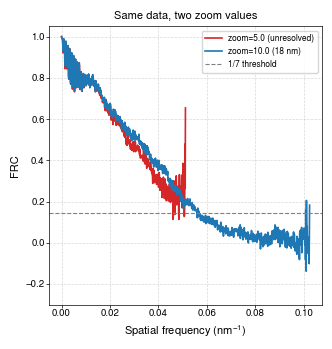

In [4]:
fig, ax = plotter.create_figure()
for zoom, color in [(5.0, "tab:red"), (10.0, "tab:blue")]:
    res, curve = results[zoom]
    sz = max(int(width * zoom), int(height * zoom))
    q_per_nm = (np.arange(len(curve)) / sz) / (pixel_size_nm / zoom)
    label = f"zoom={zoom} ({'unresolved' if not np.isfinite(res) else f'{res:.0f} nm'})"
    plotter.line_plot(ax, q_per_nm, curve, xlabel="Spatial frequency (nm$^{-1}$)", ylabel="FRC",
                       ylim=(-0.3, 1.05), color=color, linewidth=1.2, label=label)
ax.axhline(1.0 / 7.0, color="gray", ls="--", lw=0.8, label="1/7 threshold")
ax.legend()
ax.set_title("Same data, two zoom values")
plt.tight_layout()
plt.show()

## Takeaway

Getting "unresolved" from `fire()` doesn't necessarily mean the data is too sparse or too
poor — it can just as easily mean `zoom` wasn't high enough to probe down to where the data
actually resolves, especially for heavily-oversampled data like this fixture. Always sweep
`zoom` upward before concluding a dataset genuinely doesn't resolve; the GUI's FRC panel
defaults to `zoom=5.0`, which is a reasonable starting point but not a guarantee.

## Next: `../simulations/`

This is the last of the analysis notebooks — `../simulations/` covers how every fixture
used across notebooks 01-07 was generated, and how to simulate your own acquisitions from
scratch.